# FIFA Player Similarity Project — EDA
**Öğrenci**: Ali


**Amaç:** FIFA 15 datasetini kullanarak benzer oyuncu öneri sistemi için
veri keşfi ve modelleme kararları.

## Çalışma Günlüğü
- **Gün 1 (04/13/2026):** Tanıma ve temizlik
- **Gün 2 (04/14/2026):** Derin analiz
- **Gün 3 (04/15/2026):** Anlam çıkarma ve modelleme kararları

# 📅 Gün 1 — Tanıma ve Temizlik
**Hedef:** Datasetin ne içerdiğini anlamak, çöpü ayırmak, veri tiplerini düzeltmek.

## Görev 1 — Dataset Tanışması
**Süre:** ~45 dk
**Amaç:** Datasetin boyutunu, sütun yapısını ve genel karakterini anlamak.

### Yapacaklarım:
1. Dataseti yükle, shape kontrol et
2. `df.info(verbose=True, show_counts=True)` ile tüm sütunları incele
3. `df.head(3)` ve `df.sample(5)` ile farklı satırları gör
4. 110 sütunu 10 kategoriye ayır (Python'da prefix filtering ile say)
5. Aşağıdaki 5 soruyu cevapla

In [2]:
import pandas as pd
from numpy.testing.print_coercion_tables import print_new_cast_table
from pydantic_core.core_schema import model_field


In [3]:
df  = pd.read_csv("players_15.csv", low_memory=False)

In [4]:
df.head()

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,...,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,...,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png,https://cdn.sofifa.net/teams/243/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,...,46+3,46+3,46+3,55+3,14+3,https://cdn.sofifa.net/players/009/014/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/105035/60.png,https://cdn.sofifa.net/flags/nl.png
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,52500000.0,275000.0,32,...,55+3,55+3,55+3,56+3,17+3,https://cdn.sofifa.net/players/041/236/15_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1363/60.png,https://cdn.sofifa.net/flags/se.png
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Peter Neuer,GK,90,90,63500000.0,300000.0,28,...,38+3,38+3,38+3,36+3,87+3,https://cdn.sofifa.net/players/167/495/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1337/60.png,https://cdn.sofifa.net/flags/de.png


In [5]:
df.info(verbose=True,show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16155 entries, 0 to 16154
Data columns (total 110 columns):
 #    Column                       Non-Null Count  Dtype  
---   ------                       --------------  -----  
 0    sofifa_id                    16155 non-null  int64  
 1    player_url                   16155 non-null  object 
 2    short_name                   16155 non-null  object 
 3    long_name                    16155 non-null  object 
 4    player_positions             16155 non-null  object 
 5    overall                      16155 non-null  int64  
 6    potential                    16155 non-null  int64  
 7    value_eur                    15844 non-null  float64
 8    wage_eur                     15916 non-null  float64
 9    age                          16155 non-null  int64  
 10   dob                          16155 non-null  object 
 11   height_cm                    16155 non-null  int64  
 12   weight_kg                    16155 non-null  int64  
 13  

In [6]:
df.head(5)

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,...,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,...,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png,https://cdn.sofifa.net/teams/243/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,...,46+3,46+3,46+3,55+3,14+3,https://cdn.sofifa.net/players/009/014/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/105035/60.png,https://cdn.sofifa.net/flags/nl.png
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,52500000.0,275000.0,32,...,55+3,55+3,55+3,56+3,17+3,https://cdn.sofifa.net/players/041/236/15_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1363/60.png,https://cdn.sofifa.net/flags/se.png
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Peter Neuer,GK,90,90,63500000.0,300000.0,28,...,38+3,38+3,38+3,36+3,87+3,https://cdn.sofifa.net/players/167/495/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1337/60.png,https://cdn.sofifa.net/flags/de.png


In [7]:
df.sample(3)

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
8935,207614,https://sofifa.com/player/207614/tony-cascio/1...,T. Cascio,Tony Cascio,"LM, CAM",63,66,350000.0,4000.0,24,...,44,44,44,47,12,https://cdn.sofifa.net/players/207/614/15_120.png,https://cdn.sofifa.net/teams/698/60.png,https://cdn.sofifa.net/flags/us.png,NaN,https://cdn.sofifa.net/flags/us.png
5291,204627,https://sofifa.com/player/204627/kenneth-otigb...,K. Otigba,Kenneth Karim Otigba,CB,67,74,500000.0,8000.0,21,...,67,67,67,62,13,https://cdn.sofifa.net/players/204/627/15_120.png,https://cdn.sofifa.net/teams/1913/60.png,https://cdn.sofifa.net/flags/nl.png,NaN,https://cdn.sofifa.net/flags/hu.png
9748,204304,https://sofifa.com/player/204304/daniel-redmon...,D. Redmond,Daniel Stephen Redmond,"CAM, LM, LWB",62,69,350000.0,4000.0,23,...,50,50,50,54,13,https://cdn.sofifa.net/players/204/304/15_120.png,https://cdn.sofifa.net/teams/184/60.png,https://cdn.sofifa.net/flags/gb-sct.png,NaN,https://cdn.sofifa.net/flags/gb-eng.png


In [8]:
print(df.columns.tolist())

['sofifa_id', 'player_url', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_name', 'league_level', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined', 'club_contract_valid_until', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power

In [9]:
atack_filter = [ c for c in df.columns  if c.startswith("attacking_") ]
print(atack_filter)


['attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys']


In [10]:
club_cols = [z for z in df.columns if z.startswith("club_") and not z.endswith("_url")]
print(club_cols)

['club_team_id', 'club_name', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined', 'club_contract_valid_until']


In [11]:
defend_filter = [f for f in df.columns if f.startswith("defending_") ]
print(defend_filter)

['defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle']


In [12]:
goalkeep_filter  = [d for d in df.columns if d. startswith("goalkeeping") ]
print(goalkeep_filter)

['goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed']


In [13]:
skill_filter  = [d for d in df.columns if d. startswith("skill") ]
print(skill_filter)

['skill_moves', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control']


In [14]:
url_cols = [o for o in df.columns if o.endswith("_url") ]
print(url_cols)

['player_url', 'player_face_url', 'club_logo_url', 'club_flag_url', 'nation_logo_url', 'nation_flag_url']


In [15]:
nation_filter = [o for o in df.columns if o.startswith("nation") and not o.endswith("_url")]
print(nation_filter)

['nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number']


In [16]:
power_filter =  [c for c in df.columns if c.startswith("power_") ]
print(power_filter)

['power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots']


In [17]:
mentality_filter = [c for c in df.columns if c.startswith("mental") ]
print(mentality_filter)

['mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure']


In [18]:
identity_cols = ['sofifa_id', 'short_name', 'long_name']
financial_cols = ['value_eur', 'wage_eur', 'release_clause_eur']
main_stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
general_rating = ['overall', 'potential']


demographic_cols = ['age', 'dob', 'height_cm', 'weight_kg', 'body_type']
player_attribute_cols = ['preferred_foot', 'weak_foot', 'work_rate',
                         'real_face', 'international_reputation']
position_info_cols = ['player_positions']
league_cols = ['league_name', 'league_level']
tag_trait_cols = ['player_tags', 'player_traits']

position_rating_cols = ['ls','st','rs','lw','lf','cf','rf','rw',
                        'lam','cam','ram','lm','lcm','cm','rcm','rm',
                        'lwb','ldm','cdm','rdm','rwb',
                        'lb','lcb','cb','rcb','rb','gk']

In [19]:
skill_cols      = [c for c in df.columns if c.startswith('skill_')]
movement_cols   = [c for c in df.columns if c.startswith('movement_')]
power_cols      = [c for c in df.columns if c.startswith('power_')]
mentality_cols  = [c for c in df.columns if c.startswith('mentality_')]
defending_cols  = [c for c in df.columns if c.startswith('defending_')]
goalkeeping_cols = [c for c in df.columns if c.startswith('goalkeeping_')]

In [20]:
all_categories = {
    "Identity": identity_cols,
    "Demographics": demographic_cols,
    "Player Attributes": player_attribute_cols,
    "Position Info": position_info_cols,
    "Club Info": club_cols,
    "League Info": league_cols,
    "Nation Info": nation_filter,
    "General Rating": general_rating,
    "Financial": financial_cols,
    "6 Main Stats": main_stats,
    "Sub Stats - Attacking": atack_filter,
    "Sub Stats - Skill": skill_cols,
    "Sub Stats - Movement": movement_cols,
    "Sub Stats - Power": power_cols,
    "Sub Stats - Mentality": mentality_cols,
    "Sub Stats - Defending": defend_filter,
    "Goalkeeping": goalkeep_filter,
    "Position Ratings": position_rating_cols,
    "Tags & Traits": tag_trait_cols,
    "URL/Visual": url_cols,
}
total = 0
for name, cols in all_categories.items():
    print(f"{name}: {len(cols)}")
    total += len(cols)

print(f"\nTOTAL: {total}")
print(f"Expected: {len(df.columns)}")


Identity: 3
Demographics: 5
Player Attributes: 5
Position Info: 1
Club Info: 7
League Info: 2
Nation Info: 5
General Rating: 2
Financial: 3
6 Main Stats: 6
Sub Stats - Attacking: 5
Sub Stats - Skill: 6
Sub Stats - Movement: 5
Sub Stats - Power: 5
Sub Stats - Mentality: 6
Sub Stats - Defending: 3
Goalkeeping: 6
Position Ratings: 27
Tags & Traits: 2
URL/Visual: 6

TOTAL: 110
Expected: 110


### Question 1.1: What does `object` dtype mean?

In the `df.info()` output, I saw that some columns are not `int64` or
`float64`, but `object` type.

- What does `object` dtype mean in pandas?
- Which columns in this dataset are `object` type, and why?
- Does `object` type stop me from doing math operations on a column?

#### My answer:
[1)object data type is include string variables phyton is a low level language in OOP  language  there is no string variables so thats why
 2)for find which columns are `object` type ı use select_dtype() func and there is the results
 object_columns = df.select_dtypes(object).columns
object_columns
3 ) in pandas u it doesnt u  can do any operation with object col like "abc"+"de"= "abcde"
 ]

### real answer :
[Pandas is built on NumPy, and NumPy works best with fixed-size numeric types like int64 or float64. But strings have different lengths (one player name is "Pelé", another is "Cristiano Ronaldo dos Santos Aveiro"). NumPy cannot store them in a fixed-size array. So pandas uses object dtype, which is a generic Python container that can hold anything — strings, lists, dicts, mixed types. That's why string columns become object]

### Question 1.2: Column categories and counts

I split the 110 columns into categories. I used Python with prefix
filtering to count them automatically, and I wrote some lists by hand
for columns without a clean prefix.

#### My answer:

| Category | Column Count | Example Columns |
|----------|--------------|-----------------|
| Identity | ? | sofifa_id, short_name, ... |
| Demographics | ? | age, height_cm, dob, ... |
| Player Attributes | ? | preferred_foot, work_rate, ... |
| Position Info | ? | player_positions |
| Club Info | ? | club_name, club_position, ... |
| League Info | ? | league_name, league_level |
| Nation Info | ? | nationality_name, nation_position, ... |
| General Rating | ? | overall, potential |
| Financial | ? | value_eur, wage_eur, ... |
| 6 Main Stats | ? | pace, shooting, passing, ... |
| Sub Stats - Attacking | ? | attacking_finishing, ... |
| Sub Stats - Skill | ? | skill_dribbling, ... |
| Sub Stats - Movement | ? | movement_sprint_speed, ... |
| Sub Stats - Power | ? | power_shot_power, ... |
| Sub Stats - Mentality | ? | mentality_vision, ... |
| Sub Stats - Defending | ? | defending_marking, ... |
| Goalkeeping | ? | goalkeeping_diving, ... |
| Position Ratings | ? | ls, st, cm, cb, gk, ... |
| Tags & Traits | ? | player_tags, player_traits |
| URL/Visual | ? | player_face_url, club_logo_url, ... |
| **TOTAL** | **110** | |

Identity: 3
Demographics: 5
Player Attributes: 5
Position Info: 1
Club Info: 7
League Info: 2
Nation Info: 5
General Rating: 2
Financial: 3
6 Main Stats: 6
Sub Stats - Attacking: 5
Sub Stats - Skill: 6
Sub Stats - Movement: 5
Sub Stats - Power: 5
Sub Stats - Mentality: 6
Sub Stats - Defending: 3
Goalkeeping: 6
Position Ratings: 27
Tags & Traits: 2
URL/Visual: 6


### Question 1.3: Did anything surprise you?

While exploring the data with `head`, `sample`, and `info`, did you find
something unexpected or interesting?

**Hints — places to look:**
- How is the `player_positions` column written? (one value or a list with commas?)
- What is the format of `ls`, `st`, `rs` and other position rating columns?
  Just a number, or something like "85+2"?
- What are the values inside `work_rate`?
- Are there any unexpected null values?

#### My answer:
[write at least 2-3 observations]

In [21]:
 #How is the `player_positions` column written? (one value or a list with commas?)
#on player_positions there are save as a list
(df["player_positions"]).dtypes ## bu yanlış çünkü list oludğu için object döndü eğer :
print(type(df['player_positions'].iloc[0]))# geri string döner bu ilk elemanın değeri
print(df['player_positions'].iloc[0])


<class 'str'>
CF


In [22]:
#- What is the format of `ls`, `st`, `rs` and other position rating columns?
#they are all like 93+3 and ı dont know why
df["ls"]
#base rating (93) for that position, and the +3 is a chemistry bonus — extra points if the player is in a good team formation. So 93+3 means "93 base, +3 from chemistry"


0        89+3
1        91+1
2        84+3
3        87+3
4        38+3
         ... 
16150      32
16151      41
16152      38
16153      38
16154      35
Name: ls, Length: 16155, dtype: object

In [23]:
#- What are the values inside `work_rate`?
df["work_rate"]
#its all  like Medium/Low ıt can be traning rate of player

0           Medium/Low
1             High/Low
2             High/Low
3           Medium/Low
4        Medium/Medium
             ...      
16150    Medium/Medium
16151    Medium/Medium
16152    Medium/Medium
16153    Medium/Medium
16154    Medium/Medium
Name: work_rate, Length: 16155, dtype: object

In [24]:
#- Are there any unexpected null values?
#yes there are
df.isnull().sum()


sofifa_id               0
player_url              0
short_name              0
long_name               0
player_positions        0
                    ...  
player_face_url         0
club_logo_url         239
club_flag_url         239
nation_logo_url     15074
nation_flag_url         0
Length: 110, dtype: int64

### Question 1.4: Columns I don't understand

#I am not sure what these columns mean. I will ask my mentor about them.

#### My list:
/#
player_positions : how can   ı use it some player have multiple position
club_position : what is the different wth player position
["club_loaned_from"] : why there is to many nan
work_rate : how can ı work with it
international_reputation :  what it mean
real_face : what it presenting
release_clause_eur : ??

#/
df.head()

In [25]:
df["club_loaned_from"].unique()

array([nan, 'AS Monaco', 'Manchester City', 'Chelsea',
       'Manchester United', 'FC Barcelona', 'SL Benfica', 'Valencia CF',
       'Newcastle United', 'Swansea City', 'FC Porto', 'Cagliari',
       'Atlético de Madrid', 'FC Schalke 04', 'Rubin Kazan', 'Fulham',
       'Palermo', 'Zenit St. Petersburg', 'Southampton', 'Galatasaray SK',
       'Tottenham Hotspur', 'Udinese Calcio', 'Toulouse Football Club',
       'Bayer 04 Leverkusen', 'Napoli', 'PSV', 'Juventus', 'Liverpool',
       'Real Madrid CF', 'Sevilla FC', 'AC Milan', 'PFC CSKA Moscow',
       'Spartak Moskva', 'Roma', 'RC Celta de Vigo', 'Real Valladolid CF',
       'Inter', 'Beşiktaş JK', 'KRC Genk', 'Fiorentina', 'Sporting CP',
       'PAOK', 'Borussia Dortmund', 'Catania', '1. FSV Mainz 05',
       'Granada CF', 'Norwich City', 'Olympique de Marseille', 'Elche CF',
       'FC Bayern München', 'Villarreal CF', 'Arsenal', 'Real Zaragoza',
       'Club Deportivo Guadalajara', 'Real Sociedad', 'SC Braga',
       'RCD Espany

In [26]:
df["body_type"].unique()


array(['Normal (170-)', 'Normal (185+)', 'Normal (170-185)',
       'Lean (170-185)', 'Lean (185+)', 'Stocky (170-185)',
       'Stocky (170-)', 'Stocky (185+)', 'Lean (170-)', 'Unique'],
      dtype=object)

In [27]:
df[df["body_type"]=='Unique']

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
901,51257,https://sofifa.com/player/51257/peter-crouch/1...,P. Crouch,Peter Crouch,ST,75,75,2300000.0,30000.0,33,...,48+1,48+1,48+1,50+1,16+1,https://cdn.sofifa.net/players/051/257/15_120.png,https://cdn.sofifa.net/teams/1806/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/gb-eng.png
14710,213797,https://sofifa.com/player/213797/joe-bunney/15...,J. Bunney,Joseph Elliott Bunney,"ST, RM",54,60,90000.0,2000.0,20,...,38,38,38,38,14,https://cdn.sofifa.net/players/213/797/15_120.png,https://cdn.sofifa.net/teams/1955/60.png,https://cdn.sofifa.net/flags/gb-eng.png,NaN,https://cdn.sofifa.net/flags/gb-eng.png


In [28]:
df["mentality_composure"].unique()

array([nan])

### Question 1.5: Task 1 Summary

In one paragraph, in your own words: what is in this dataset, how many
players, what kind of information does it have, and what is your first
impression for our project (similar player recommendation system)?

#### My answer:
This dataset contains FIFA 15 player data with 16,155 rows and 110 columns.
Each row is one player, and the columns can be grouped into 10 main
categories: identity, demographics, club info, financial data, general
ratings (overall/potential), six main stats (pace, shooting, passing,
dribbling, defending, physic), detailed sub-stats, goalkeeper stats,
position-specific ratings for 27 positions, and URLs.

I noticed some problems: a few columns are 100% null (release_clause_eur,
mentality_composure), some columns have unexpected data types like the
position ratings stored as "93+3" strings, and the player_positions column
contains multiple values separated by commas.

For our similar-player recommendation project, this dataset looks rich
enough to start, but I will need to clean and convert several columns
before I can use them in a similarity model. The biggest question for me
is how to handle goalkeepers — their stats are very different from other
players and they probably need a separate pipeline.

## Görev 2 — Missing Value Analysis
**Süre:** ~40 dk
**Amaç:** Hangi sütunlar boş, neden boş, ne yapacağız?

### What I will do:
1. Calculate missing count and percentage for every column
2. Visualize top 20 columns with most missing values (bar chart)
3. Investigate why `pace, shooting, passing, dribbling, defending, physic`
   have exactly **1775** missing values
4. Decide which columns to drop, fill, or keep

### Step 1: Build a missing value table

I need a DataFrame with two columns:
- `missing_count` — how many nulls per column
- `missing_pct` — percentage of nulls per column

Then sort by `missing_count` descending and show only columns with at
least 1 null.

**Hints:**
- `df.isnull().sum()` gives count
- `len(df)` gives total rows
- Build a new DataFrame with `pd.DataFrame({...})`

In [29]:

missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2)
})



missing_df.sort_values(by="missing_count", ascending=False ,inplace= True)

missing_df = missing_df[missing_df["missing_count"]>0]
print(type(missing_df))
print(missing_df.shape)
missing_df



<class 'pandas.core.frame.DataFrame'>
(28, 2)


,missing_count,missing_pct
mentality_composure,16155,100.00
release_clause_eur,16155,100.00
club_loaned_from,15243,94.35
nation_position,15074,93.31
nation_logo_url,15074,93.31
nation_jersey_number,15074,93.31
nation_team_id,15074,93.31
player_tags,14919,92.35
goalkeeping_speed,14380,89.01
player_traits,9556,59.15


### Step 2: Visualize top 20 columns with most missing values

Create a horizontal bar chart (`plt.barh`) showing the top 20 columns
with the highest missing percentage.

**Hints:**
- `import matplotlib.pyplot as plt`
- Use `.head(20)` on your missing table
- `plt.figure(figsize=(10, 6))` for a good size
- Add title, xlabel, and `plt.tight_layout()`

In [30]:
import matplotlib.pyplot as plt


<Figure size 1000x600 with 0 Axes>

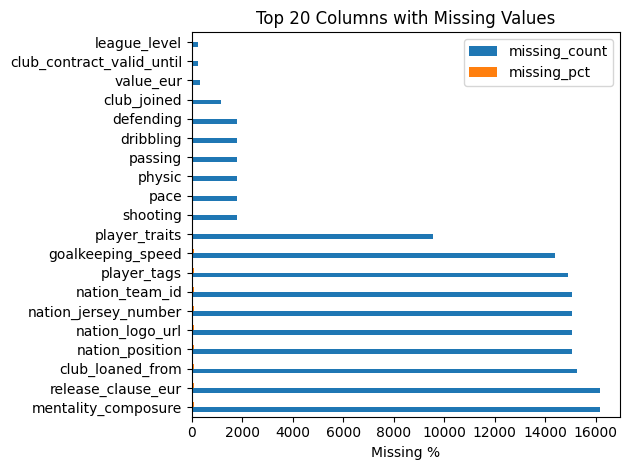

In [31]:
plt.figure(figsize=(10,6))
missing_df.head(20).plot(kind="barh")
plt.xlabel("Missing %")
plt.title("Top 20 Columns with Missing Values")
plt.tight_layout()
plt.show()

### Step 3: Investigate the 1775 mystery

Six columns have exactly 1775 missing values: `pace, shooting, passing,
dribbling, defending, physic`. This is not random. Find out **who** these
1775 players are.

**Hint:** Filter rows where `pace` is null, then look at the
`player_positions` column with `.value_counts()`.

In [32]:
pace_null= df[df["pace"].isnull()]
pace_null["player_positions"].value_counts()
#[all of GoalKeepers have null `pace, shooting, passing,dribbling, defending, physic`]


player_positions
GK    1775
Name: count, dtype: int64

### Step 4: Confirm the goalkeeper hypothesis

If your Step 3 result shows mostly "GK", prove it with numbers:
- Count total goalkeepers in the dataset
- Compare with the number of null `pace` values
- They should match exactly

**Hint:** Use `.shape[0]` to count rows after filtering.

In [33]:
a = len(df[df["player_positions"]=="GK"])
b = (df.pace.isnull().sum())

print(f"Total GoalKeepers:{a}")
print(f"number of pace null players:{b}")
print(f"is Match: {a==b}")


Total GoalKeepers:1775
number of pace null players:1775
is Match: True


### Question 2.1: 100% Empty Columns

Which columns are completely empty (100% null)? Why might they be empty,
and is it safe to drop them?

**Think about:** This dataset is FIFA **15** (released in 2014). Some
columns might exist because the CSV format is shared across all FIFA
versions, but the feature was only added in later games.

#### My answer:
- 100% empty columns:['release_clause_eur', 'mentality_composure']
- Why they might be empty (my hypothesis): this features can not be added on this version of game
- Decision (drop / keep / something else): i will drop beaceuse ı have any value for fill

In [34]:
empty_cols = [c for c in df.columns if df[c].isnull().all()]
print(empty_cols)


['release_clause_eur', 'mentality_composure']


### Question 2.2: The 1775 Mystery — Solved

I investigated why `pace, shooting, passing, dribbling, defending, physic`
have exactly 1775 missing values.

#### My answer:
- Who are these 1775 players? : All GK
- Why don't they have these stats? : may spesificly goalkeeper they have no value on there cart like that
- What does this mean for our project (similar player recommendation)?: What does this mean for our project? Goalkeepers and outfield
  players have completely different feature sets. We should build
  TWO separate similarity pipelines: one for outfield players using
  the 6 main stats + sub-stats, one for goalkeepers using only
  goalkeeping_* features. Mixing them in one model would break
  similarity calculations.

### Question 2.3: My Strategy — Drop, Fill, or Keep

Based on the missing value analysis, here is my plan for each problematic
column.

#### My answer: ['release_clause_eur', 'mentality_composure'] DROP
club_loaned_from KEEP
nation_team_id, nation_position, nation_jersey_number, nation_logo_url KEEP
player_tags, player_traits DROP
pace, shooting, ..., physic KEEP WE MAKE ANOTHER PİPELİNE FOR GK

**Columns I will DROP (>90% null or useless):**
-['release_clause_eur', 'mentality_composure'],player_tags, player_traits DROP

**Columns I will FILL (and how):**
| Column | Fill method | Why |
|--------|-------------|-----|
|value_eur| median            |  few nulls   |
'wage_eur|   median           |   few nulls


**Columns I will KEEP as-is (null is meaningful):**
-club_loaned_from KEEP
-nation_team_id, nation_position, nation_jersey_number, nation_logo_url KEEP
-player_tags, player_traits DROP
-pace, shooting, ..., physic KEEP WE MAKE ANOTHER PİPELİNE FOR GK

In [35]:
missing_df.loc[['value_eur', 'wage_eur', 'club_position']]

,missing_count,missing_pct
value_eur,311,1.93
wage_eur,239,1.48
club_position,239,1.48


## Görev 3 — Data Type Fixes
**Süre:** ~30 dk
**Amaç:** Convert columns with wrong dtypes so we can use them in
calculations later.

### What I will do:
1. Inspect position rating columns (`ls`, `st`, ..., `gk`) — confirm "93+3" format
2. Parse them: extract the base number (93) and convert to int
3. Convert `dob` (date of birth) to datetime
4. Convert `club_joined` to datetime

### Step 1: Inspect position rating columns

Look at 3-4 position rating columns to confirm the `"93+3"` string format
and check their dtype.

**Hint:** Use `df[['ls', 'st', 'cm', 'gk']].head(5)` and `.dtypes`.

In [36]:
df[["ls","st","cm","gk"]].head(5)

,ls,st,cm,gk
0,89+3,89+3,79+3,15+3
1,91+1,91+1,77+3,16+3
2,84+3,84+3,78+3,14+3
3,87+3,87+3,76+3,17+3
4,38+3,38+3,36+3,87+3


In [37]:
(df[["ls","st","cm","gk"]].iloc[0]).dtypes

dtype('O')

### Mini investigation before Step 2

Before we parse `"93+3"`, we need to know if all values use `+`
or some use `-`. Run this:

​```python
df['ls'].str.contains('-', na=False).sum()
​```

If result > 0, some values are `"93-2"` format (subtraction!).
If result == 0, only `+` exists, parsing is simpler.

#### My finding:
[SUB CONTAİNS :     LS --> 111 /     ST --> 111   / CM -->85    /   GK --->0 ]

In [38]:
print(df["ls"].str.contains("-",na=False).sum())
print(df["st"].str.contains("-",na=False).sum())
print(df["cm"].str.contains("-",na=False).sum())
print(df["gk"].str.contains("-",na=False).sum())



111
111
85
0


### Step 2: Parse "93+3" → 93 for all 27 position rating columns

We want only the **base rating** (number before `+` or `-`).

**Strategy:**
- Use `pd.to_numeric()` with `errors='coerce'` — but first split on the operator
- A cleaner way: use regex to extract only the leading digits

**Approach 1 — string split (works if only `+`):**
​```python
df['ls'].str.split('+').str[0].astype(int)
​```

**Approach 2 — regex (works for `+` and `-`):**
​```python
df['ls'].str.extract(r'(\d+)').astype(int)
​```

**Your task:**
1. Test on ONE column first (`ls`)
2. Print the first 5 values to confirm
3. Apply to all 27 position rating columns using a `for` loop

(Yes, here a loop is fine — we want to update 27 separate columns,
this is one of the rare cases pandas needs explicit iteration.)

**Use `position_rating_cols` list from Cell 19** — already defined.

In [39]:
#df["ls"]=df["ls"].str.split(pat= "+").str[0].astype(int)
##df["ls"] = df["ls"].str.split(pat = "-").str[0].astype(int)
#df["ls"]
###burada yaptığım hatalı çünkü önce 1. satırda inte çevirip sonra tekrar str metdou üzerine işlem yapmaya çalıyorum bu hatalı burada iki pattern olduğu için regex şart + -
test = df["ls"].str.extract(r'(\d+)').astype(int)
print(test.head(2))
print(test.dtypes)


    0
0  89
1  91
0    int64
dtype: object


In [40]:
import pandas as pd
# Mini test
test_data = pd.Series(["93+3", "85-2", "70+0", "60", "90+5"])
print("Original:")
print(test_data)
print()
print("After extract:")
print(test_data.str.extract(r'(\d+)'))
# r"(\d+)" burada r: raw string içerdeki \d+ bana birden fazla(+ile sağlandı) rakam getir demek d : rakam


Original:
0    93+3
1    85-2
2    70+0
3      60
4    90+5
dtype: object

After extract:
    0
0  93
1  85
2  70
3  60
4  90


In [41]:
import pandas as pd

ex1 = pd.Series([
    "Match 93: Liverpool vs Chelsea",
    "Year 2024 was great",
    "Flight AB123 departed at 17:45",
    "Score was 7-2 yesterday",
    "No numbers here"
])
ex1 = ex1.str.extract(r"(\d{2})")
print(ex1)

     0
0   93
1   20
2   12
3  NaN
4  NaN


In [42]:
ex2 = pd.Series([
    "Messi_10",
    "Ronaldo",
    "Neymar Jr",
    "Van der Berg",
    "  spaces  "
])
ex2= ex2.str.extract(r"(\w+)")
print(ex2)

          0
0  Messi_10
1   Ronaldo
2    Neymar
3       Van
4    spaces


In [43]:
ex3 = pd.Series([
    "FIFA 15",
    "hello WORLD",
    "UEFA Champions League",
    "lowercase only",
    "MessiGOAT"
])

ex3 = ex3.str.extract(r"([A-Z]+)")
print(ex3)

       0
0   FIFA
1  WORLD
2   UEFA
3    NaN
4      M


In [44]:
for x in position_rating_cols:
   df[x]= df[x].str.extract(r'(\d+)').astype(int)

In [45]:
print(df[position_rating_cols])

       ls  st  rs  lw  lf  cf  rf  rw  lam  cam  ...  ldm  cdm  rdm  rwb  lb  \
0      89  89  89  92  90  90  90  92   92   92  ...   62   62   62   62  54   
1      91  91  91  89  91  91  91  89   89   89  ...   63   63   63   63  57   
2      84  84  84  88  87  87  87  88   88   88  ...   64   64   64   64  55   
3      87  87  87  84  86  86  86  84   86   86  ...   65   65   65   61  56   
4      38  38  38  36  37  37  37  36   36   36  ...   40   40   40   36  36   
...    ..  ..  ..  ..  ..  ..  ..  ..  ...  ...  ...  ...  ...  ...  ...  ..   
16150  32  32  32  33  30  30  30  33   30   30  ...   38   38   38   37  40   
16151  41  41  41  37  39  39  39  37   37   37  ...   30   30   30   31  32   
16152  38  38  38  41  40  40  40  41   41   41  ...   37   37   37   36  34   
16153  38  38  38  38  35  35  35  38   33   33  ...   46   46   46   48  51   
16154  35  35  35  33  33  33  33  33   31   31  ...   36   36   36   37  39   

       lcb  cb  rcb  rb  gk  
0       4

In [46]:
for x in position_rating_cols:
     print( df[x])

0        89
1        91
2        84
3        87
4        38
         ..
16150    32
16151    41
16152    38
16153    38
16154    35
Name: ls, Length: 16155, dtype: int64
0        89
1        91
2        84
3        87
4        38
         ..
16150    32
16151    41
16152    38
16153    38
16154    35
Name: st, Length: 16155, dtype: int64
0        89
1        91
2        84
3        87
4        38
         ..
16150    32
16151    41
16152    38
16153    38
16154    35
Name: rs, Length: 16155, dtype: int64
0        92
1        89
2        88
3        84
4        36
         ..
16150    33
16151    37
16152    41
16153    38
16154    33
Name: lw, Length: 16155, dtype: int64
0        90
1        91
2        87
3        86
4        37
         ..
16150    30
16151    39
16152    40
16153    35
16154    33
Name: lf, Length: 16155, dtype: int64
0        90
1        91
2        87
3        86
4        37
         ..
16150    30
16151    39
16152    40
16153    35
16154    33
Name: cf, Length: 

### Verify Step 2

After the loop, check that all 27 columns are now numeric:

​```python
df[position_rating_cols].dtypes
​```

All should show `int64` or `float64`. If any show `object`, something failed.

In [47]:
df[position_rating_cols].dtypes

ls     int64
st     int64
rs     int64
lw     int64
lf     int64
cf     int64
rf     int64
rw     int64
lam    int64
cam    int64
ram    int64
lm     int64
lcm    int64
cm     int64
rcm    int64
rm     int64
lwb    int64
ldm    int64
cdm    int64
rdm    int64
rwb    int64
lb     int64
lcb    int64
cb     int64
rcb    int64
rb     int64
gk     int64
dtype: object

### Step 3: Convert `dob` to datetime

`dob` (date of birth) is currently stored as a string. Convert to proper
datetime so we can calculate ages or "days since signing" later.

**Hint:** `pd.to_datetime(df['dob'])` then reassign to `df['dob']`.

After conversion, verify with `df['dob'].dtype` — should show `datetime64[ns]`.

In [48]:
print(type(df["dob"][0]))
print(df["dob"][0])
print(df[["dob"]].isna().value_counts())
df["dob"]= pd.to_datetime(df["dob"])
print(type(df["dob"][0]))
print(df["dob"].dtype)





<class 'str'>
1987-06-24
dob  
False    16155
Name: count, dtype: int64
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
datetime64[ns]


### Step 4: Convert `club_joined` to datetime

Same as Step 3, but for `club_joined`.

**Watch out:** Some rows might be null. Use `errors='coerce'` so invalid
values become `NaT` (Not a Time) instead of raising an error.

​```python
df['club_joined'] = pd.to_datetime(df['club_joined'], errors='coerce')
​```

Verify dtype after conversion.

In [49]:
print(df["club_joined"].dtype)
df["club_joined"] = pd.to_datetime(df["club_joined"])
print(df["club_joined"].dtype)

object
datetime64[ns]


### Question 3.1: The position rating format

What is the meaning of the `+3` part in `"93+3"`? Why does FIFA store
position ratings this way? For our similarity project, should we use
the base rating, the total (96), or both?

#### My answer:
- Meaning of `+3`: "+" or "-" came from players chemsitry with other players
- Why FIFA stores it this way: its a futre from ultimateteam mode on fifa this mode based on chemistry
- My choice for the project (base / total / both) and why: base

### Question 3.2: My data type fixes summary

| Column(s) | Old Type | New Type | Method | Why |
|-----------|----------|----------|--------|-----|
| dob | object | datetime64 | `pd.to_datetime()` | To calculate ages |
| club_joined | object | datetime64 | pd.to_datetime() | to calculate loan |
| ls, st, ..., gk (27 cols) | object | int  | str.extract() | use on our model correctly |

## 🏁 Day 1 Closing Note

### What I did today:
- Loaded FIFA 15 dataset (16,155 rows × 110 cols), categorized all
  columns into 10 logical groups (identity, stats, positions, etc.)
- Performed missing value analysis — found that release_clause_eur and
  mentality_composure are 100% null (features added in later FIFA versions)
- Discovered that exactly 1775 missing values in pace/shooting/passing/etc.
  all belong to goalkeepers — a critical insight that will shape our
  modeling pipeline (2 separate models for GK vs outfield players)
- Fixed data types: parsed "93+3" position ratings to integers using
  regex, converted dob and club_joined to datetime

### What I learned (key concepts):
- Pandas `.str` accessor: bridge between Python string methods and Series
- Regex basics: `\d+`, capture groups `()`, raw strings `r''`
- Difference between `.count()` (counts non-null) vs `.isnull().sum()`
  (counts null) — .count() fooled me at first
- When to loop vs when to vectorize: 27 columns with different names
  need a loop, but within each column, pandas is vectorized
- Defensive coding: `errors='coerce'` for robust datetime conversion

### Where I struggled the most:
- Understanding regex — specifically what `r''` means and why we need
  parentheses `()` for capture groups in `.str.extract()`
- Initially I tried `.str.split('+')` then `.str.split('-')` sequentially,
  but after first line the column became int, so second line crashed.
  Lesson: chain transformations don't work when intermediate types change.
### Ready for Day 2:
- [ x] Notebook saved
- [ x] All cells run without errors
- [x ] Sent "Day 1 done" to mentor

# 📅 Day 2 — Deep Analysis
**Goal:** Understand how the data behaves. Find patterns, distributions,
and relationships between features. Every chart needs a 1-sentence comment.

**Tasks today:**
- Task 4: Position Analysis (most important)
- Task 5: Distribution Analysis
- Task 6: Age vs Potential
- Task 7: Correlation Matrix

## Task 4 — Position Analysis
**Time:** ~50 min
**Why this matters:** Our project recommends similar players FOR A POSITION.
If we don't understand positions, we can't filter or group players correctly.

### Step 1: How is `player_positions` stored?

Look at the first 10 values. Is it a single value like `"ST"` or
multiple values like `"ST, CF"`? Check with `.value_counts()` too —
how many unique combinations exist?

In [50]:
df["player_positions"].value_counts().sort_values(ascending=False)

player_positions
CB                 1853
GK                 1775
ST                 1677
CM                  806
LB                  623
                   ... 
RM, RW, ST, RB        1
RB, RW, RM            1
LB, CB, LWB           1
CDM, RB, CB, CM       1
CM, ST, LM            1
Name: count, Length: 907, dtype: int64

### Step 2: How many players have multiple positions?

Count how many players have a comma in their `player_positions` value.

**Hint:** `.str.contains(',')` returns True/False for each row.
Then `.sum()` counts the Trues.

#### My answer:
- Players with 1 position: 10243
- Players with 2+ positions: 5231
- What percentage has multiple positions: 46%

In [51]:
one_positions = (~( df["player_positions"].str.count(",").sum()))
print(one_positions)
total = print(df["player_positions"].str.contains(",").sum())
three_positions=print((df["player_positions"].str.count(",")==2).sum())
two_positions = print((df["player_positions"].str.count(",")==1).sum())
four_positions = print((df["player_positions"].str.count(",")==3).sum())



-10243
7501
1799
5231
471


In [52]:
multiple_prc = (df["player_positions"].str.contains(",").sum())/ df["player_positions"].count()
multiple_prc = multiple_prc*100
print(multiple_prc)

46.431445372949554


### Step 3: Extract the PRIMARY position

For our project, each player needs ONE main position. The first position
in the list is usually the primary one.

Create a new column called `main_position`:

**Hint:** `.str.split(', ').str[0]` — split by comma+space, take first element.

After creating it, check: `df['main_position'].nunique()` — how many
unique positions exist?

In [53]:
df["main_position"]=df["player_positions"].str.split(", ").str[0]
#split cf,cdm,fd yi liste çevirir [ "cf","cdm","fd"] .str ile ilk elemanını alır

In [54]:
df["main_position"].nunique()

15

### Step 4: Position frequency bar chart

Make a bar chart showing how many players play each position
(using `main_position`).

**Hint:** `df['main_position'].value_counts()` gives you the data.
Then `.plot(kind='bar')` or use `plt.bar()`.

Add title, labels, and `figsize=(12,5)` so all position names are readable.

#### My observation (1 sentence):
[CB ,ST most popular ones/ LWB AND RWB Are rare  ]

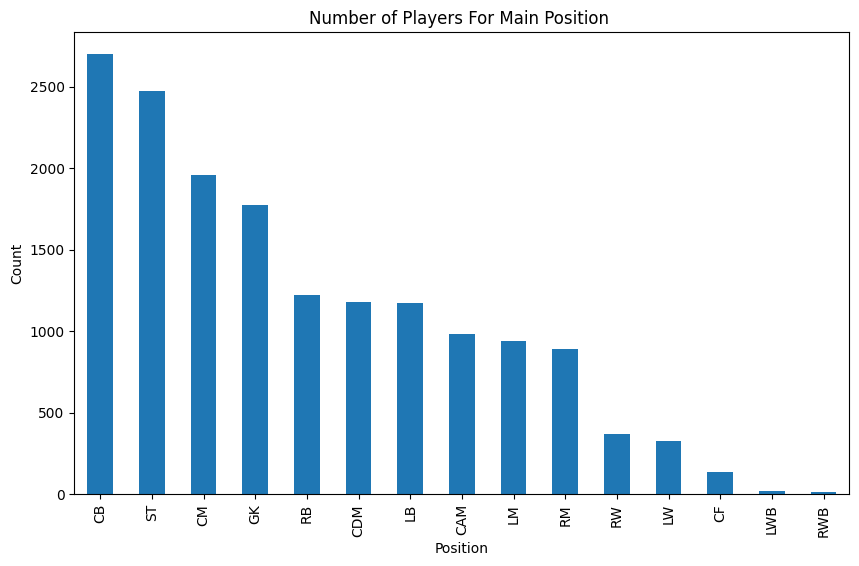

In [55]:
plt.figure(figsize=(10,6))
df["main_position"].value_counts().plot(kind="bar")
plt.title("Number of Players For Main Position ")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

**### Step 5: Group positions into 4 categories

Create a new column `position_group` with 4 values:
- **Forward:** ST, CF, LW, RW, LF, RF
- **Midfielder:** _CAM, CM, CDM, LM, RM, LAM, RAM, LCM, RCM, LDM, RDM_
- **Defender:** CB, LB, RB, LWB, RWB, LCB, RCB
- **Goalkeeper:** GK

**Approach:** Write a function that takes a position string and returns
the group. Then use `.map()` or `.apply()` on `main_position`.


In [56]:
def get_position_group(pos):
    forwards =  ["ST", "CF", "LW", "RW", "LF", "RF"]
    midfielders = ["CAM", "CM", "CDM", "LM", "RM", "LAM", "RAM", "LCM", "RCM", "LDM", "RDM"]
    defenders = ["CB", "LB", "RB", "LWB", "RWB", "LCB", "RCB"]
    goalkeepers = ["GK"]
    if pos in forwards:
        return "Forward"
    elif pos in midfielders:
        return "Midfielder"
    elif pos in defenders:
         return "Defender"
    elif pos in goalkeepers:
        return "Goalkeeper"
    else:
        return "Unknown"


In [57]:
df["position_group"]= df["main_position"].apply(get_position_group)

In [58]:
df["position_group"].value_counts().sort_values(ascending=False)

position_group
Midfielder    5952
Defender      5123
Forward       3305
Goalkeeper    1775
Name: count, dtype: int64

### Step 6: Position group bar chart

Make a bar chart of `position_group` value counts.
This should show 4 bars: Forward, Midfielder, Defender, Goalkeeper.

#### My answer:
| Group | Count |
|-------|-------|
| Forward | ? |
| Midfielder | ? |
| Defender | ? |
| Goalkeeper | ? |
| **Total** | **16155** |

<Axes: xlabel='position_group'>

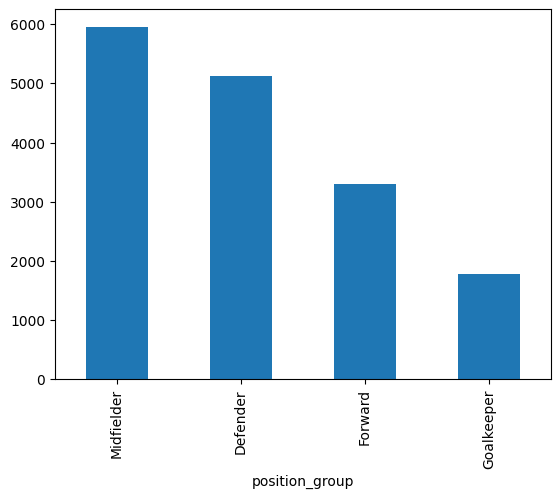

In [59]:
df["position_group"].value_counts().plot(kind="bar")

In [60]:
df["position_group"].value_counts()

position_group
Midfielder    5952
Defender      5123
Forward       3305
Goalkeeper    1775
Name: count, dtype: int64

### Question 4.1: Position decisions for our model

Now that you understand positions, answer these:

- Should we compare a ST (striker) with a CB (center back)? Why or why not?
- How will you use `main_position` in similarity calculation — as a
  **filter** (only compare same position) or as a **feature** (include
  in distance calculation)?
- What about players who can play multiple positions (e.g. "CM, CAM, CDM")?
  Are they more "similar" to more players?

#### My answer:
[-Should we compare a ST (striker) with a CB (center back)? Why or why not?
- No because every positions have indivuduals rating like defenders pys is have big difference if u compare with any wingers
- -ı will use "main_positon" as a future because a team looking for firs positon of player
- idk]


## Task 5 — Distribution Analysis
**Time:** ~30 min
**Why this matters:** If we don't know how our features are distributed,
we can't choose the right scaler or similarity metric later.

### Step 1: Histogram grid for key variables

Create a 2×3 subplot grid with histograms for:
`overall`, `potential`, `value_eur`, `wage_eur`, `age`, and
`growth` (= potential - overall, create this column first).

**Hints:**
- First create growth: `df['growth'] = df['potential'] - df['overall']`
- `fig, axes = plt.subplots(2, 3, figsize=(15, 8))` creates the grid
- `axes[0,0]` is top-left, `axes[1,2]` is bottom-right
- Use `df['column'].hist(ax=axes[row, col], bins=30)`
- Add `axes[row, col].set_title('Column Name')` for each

#### My observation for each:
- overall: [normal? skewed?]
- potential: [similar to overall?]
- value_eur: [skewed? how much?]
- wage_eur: [similar to value?]
- age: [what shape?]
- growth: [what does it tell us?]

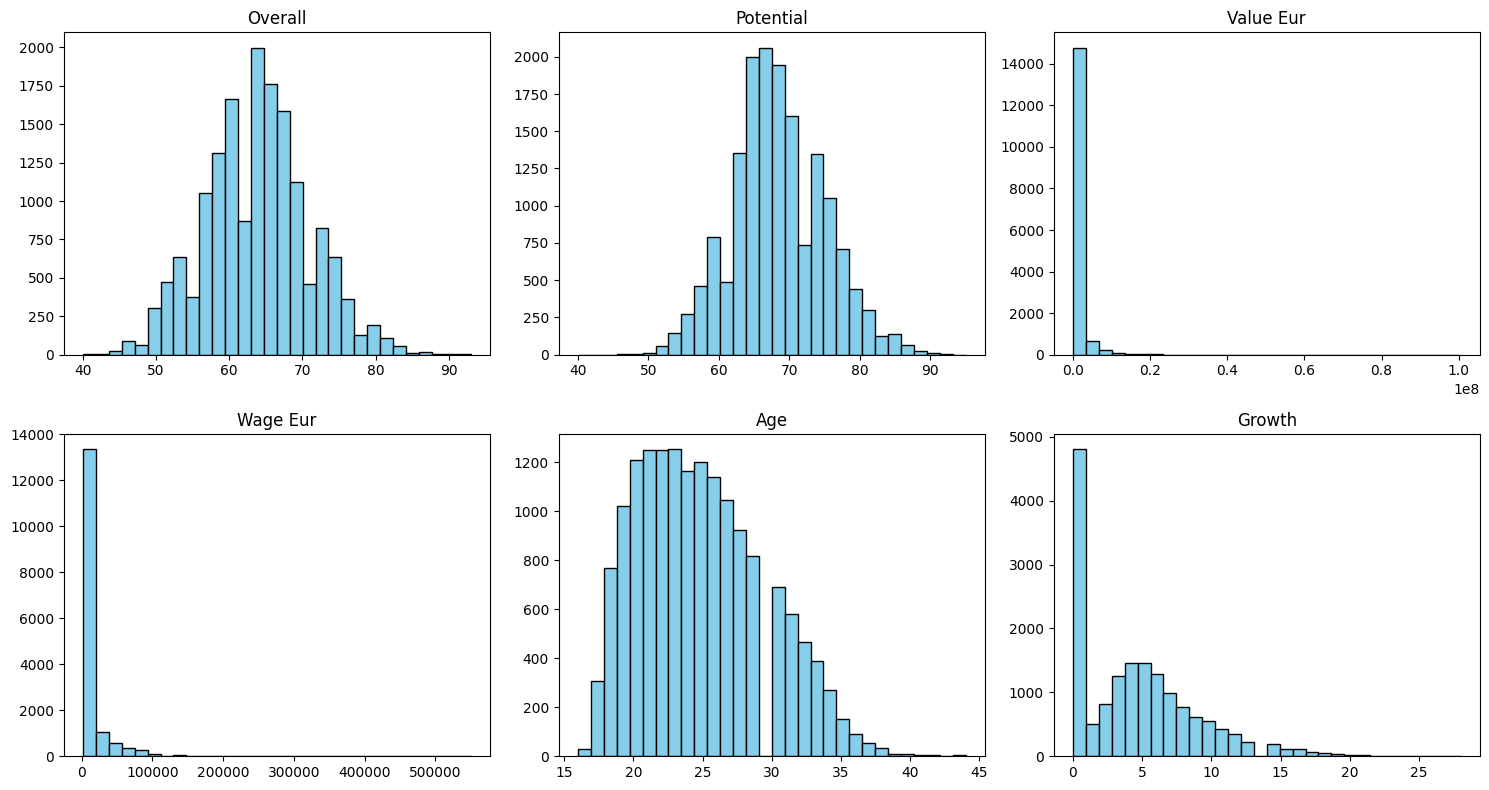

In [68]:


# 1. Create the growth column
df['growth'] = df['potential'] - df['overall']

# 2. Define the columns to plot
cols = ["overall", "potential", "value_eur", "wage_eur", "age", "growth"]

# 3. Create the 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 4. Flatten the axes for easy iteration
axes_flat = axes.flatten()

# 5. Loop through columns and axes to plot
for i, col in enumerate(cols):
    df[col].hist(ax=axes_flat[i], bins=30, color='skyblue', edgecolor='black')
    axes_flat[i].set_title(col.replace('_', ' ').title())
    axes_flat[i].grid(False) # Optional: cleans up the background

# Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()